In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [15]:
classes = pd.read_csv('class.tsv', header=None, names=['ER_Status'])
expression_data = pd.read_csv('filtered.tsv.gz', sep='\t')
expression_data.columns = expression_data.columns.astype(str).str.strip()
columns_map = pd.read_csv('columns.tsv.gz', sep='\t', comment='#')

In [16]:
xbp1_id = columns_map.loc[columns_map['GeneSymbol'] == 'XBP1', 'ID'].values[0]
gata3_id = columns_map.loc[columns_map['GeneSymbol'] == 'GATA3', 'ID'].values[0]
xbp1_col = str(xbp1_id)
gata3_col = str(gata3_id)

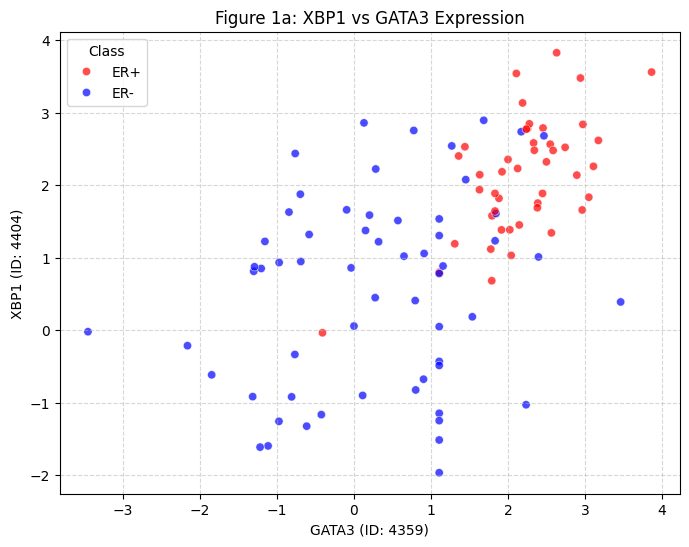

In [17]:
plot_1a_data = pd.DataFrame({
    'XBP1': expression_data[xbp1_col],
    'GATA3': expression_data[gata3_col],
    'Class': classes['ER_Status'].map({1: 'ER+', 0: 'ER-'})
})
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_1a_data, 
    x='GATA3', 
    y='XBP1', 
    hue='Class', 
    palette={'ER+': 'red', 'ER-': 'blue'},
    alpha=0.7
)
plt.title('Figure 1a: XBP1 vs GATA3 Expression')
plt.xlabel(f'GATA3 (ID: {gata3_id})')
plt.ylabel(f'XBP1 (ID: {xbp1_id})')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [18]:
matrix_2d = plot_1a_data[['GATA3', 'XBP1']] 
pca = PCA(n_components=1)
pc1_values = pca.fit_transform(matrix_2d)
pca_data = pd.DataFrame({
    'PC1': pc1_values.flatten(),
    'Class': classes['ER_Status'].map({1: 'ER+', 0: 'ER-'})
})

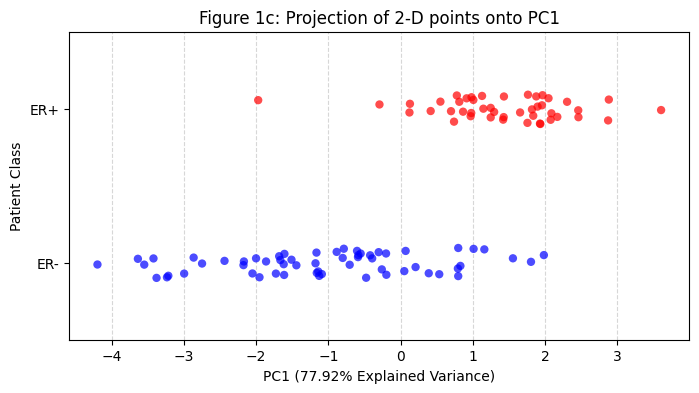

In [19]:
plt.figure(figsize=(8, 4))
sns.stripplot(
    data=pca_data, 
    x='PC1', 
    y='Class', 
    hue='Class',
    palette={'ER+': 'red', 'ER-': 'blue'},
    jitter=True, 
    alpha=0.7,
    size=6
)
plt.title('Figure 1c: Projection of 2-D points onto PC1')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Explained Variance)')
plt.ylabel('Patient Class')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend([],[], frameon=False)
plt.show()